# 전력수요·송전 인프라·지역사회 부담 통합 분석

이 Notebook은 발표와 코드 검토를 위한 **요약본**이다. 기존 작업용 Notebook을 대체하지 않으며, 최종 결과를 재현하는 핵심 코드와 시각화만 포함한다.

분석 흐름은 다음과 같다.

1. 전국 전력시설 분포 확인
2. 시도별 수요와 면적보정 송전 인프라 비교
3. 지역사회 건강부담 보조 분석
4. 제조공정 전력예측 및 생산시간 분산 시나리오

건강지표는 지역 단위의 탐색적 연관성으로만 해석하고, 제조공정 결과는 지역·공장 식별자가 없는 대표 시나리오로 해석한다.

## 재현 근거

- 세부 분석 Notebook은 개인 작업 폴더에 보관하며, 공개 저장소에는 이 통합 실행본만 제공합니다.

입력 결과는 `data/derived/`의 검증 완료 CSV를 사용한다. 원본 데이터와 인증정보는 Notebook에 포함하지 않는다.

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd()
if not (ROOT / "data" / "derived").exists():
    ROOT = ROOT.parent
DERIVED = ROOT / "data" / "derived"

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# macOS에 기본 설치된 한글 폰트를 사용한다.
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

integrated = pd.read_csv(DERIVED / "final_sido_power_health_burden_2025_2014_2018.csv")
area = pd.read_csv(DERIVED / "sido_area_adjusted_demand_infrastructure_2025_v1.csv")
health = pd.read_csv(DERIVED / "regional_health_burden_2014_2018_v2.csv")
metrics = pd.read_csv(DERIVED / "manufacturing_ai_peak_team_clean_export_model_metrics_2021_v1.csv")
scenario = pd.read_csv(DERIVED / "manufacturing_ai_peak_team_clean_export_summary_2021_v1.csv")
overlap = pd.read_csv(DERIVED / "regional_manufacturing_peak_overlap_team_clean_export_2025_v1.csv")
manufacturing = pd.read_csv(ROOT / "data" / "Untitled 7_2026-08-19-1631.csv")

print({
    "integrated_rows": len(integrated),
    "area_rows": len(area),
    "health_rows": len(health),
    "manufacturing_days": int(scenario["N_DAYS"].max()),
})

{'integrated_rows': 17, 'area_rows': 17, 'health_rows': 17, 'manufacturing_days': 255}


## 1. 전국 전력시설 분포

전력시설 지도는 별도 Notebook의 전체 geometry 결과를 사용한다. 이 통합본에서는 시설 유형과 분석 목적만 요약한다.

In [2]:
facility_summary = pd.DataFrame({
    "시설 유형": ["송전탑", "변전소", "송전선로"],
    "건수": [42263, 2313, 3663],
})
facility_summary

,시설 유형,건수
0,송전탑,42263
1,변전소,2313
2,송전선로,3663


## 2. 수요·면적보정 송전 인프라 불균형

`FINAL_GRID_BURDEN_INDEX = Z_DEMAND - AREA_ADJ_INFRA_INDEX`로 계산한 상대 지표이다.

,REGION,Z_DEMAND,AREA_ADJ_INFRA_INDEX,FINAL_GRID_BURDEN_INDEX,FINAL_RANK
0,전라남도,2.579,-0.596,3.175,1
1,경상북도,0.686,-0.689,1.375,2
2,충청남도,1.234,-0.139,1.372,3
3,경기도,1.271,0.276,0.995,4
4,인천광역시,0.263,-0.589,0.852,5


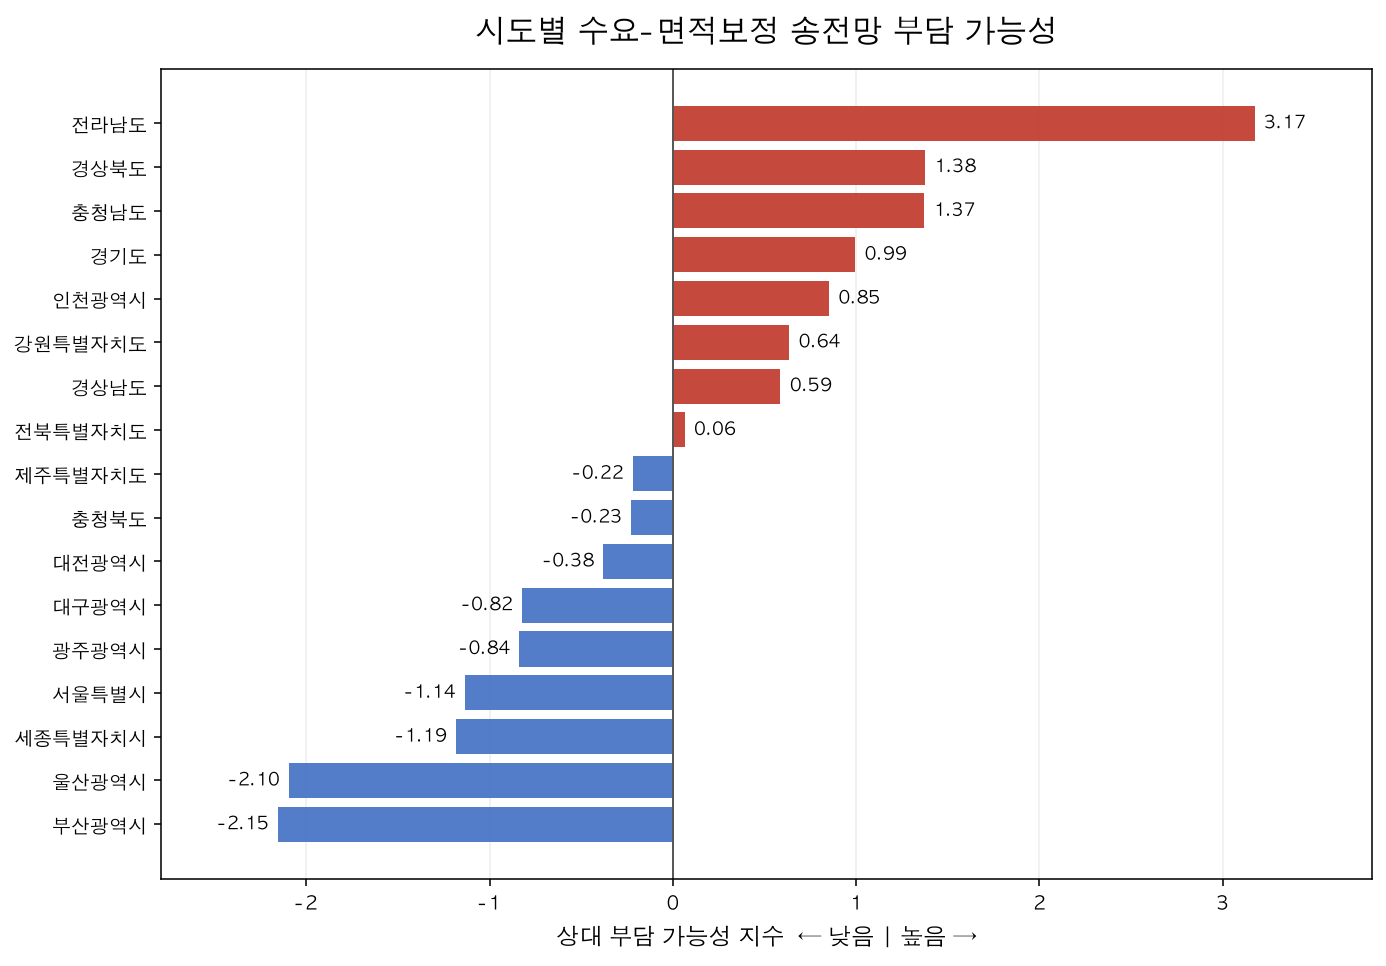

In [3]:
top5 = integrated.sort_values("FINAL_GRID_BURDEN_INDEX", ascending=False).head(5)
display(top5[["REGION", "Z_DEMAND", "AREA_ADJ_INFRA_INDEX", "FINAL_GRID_BURDEN_INDEX", "FINAL_RANK"]])

plot_df = integrated.sort_values("FINAL_GRID_BURDEN_INDEX")
bar_colors = ["#c0392b" if value > 0 else "#4472c4" for value in plot_df["FINAL_GRID_BURDEN_INDEX"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_df["REGION"], plot_df["FINAL_GRID_BURDEN_INDEX"], color=bar_colors, alpha=0.92)
ax.axvline(0, color="#555555", linewidth=1)
ax.grid(axis="x", alpha=0.22)
ax.set_axisbelow(True)
ax.set_title("시도별 수요-면적보정 송전망 부담 가능성", pad=14)
ax.set_xlabel("상대 부담 가능성 지수  ← 낮음 | 높음 →")
for bar, value in zip(bars, plot_df["FINAL_GRID_BURDEN_INDEX"]):
    offset = 0.05 if value >= 0 else -0.05
    ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:.2f}",
            va="center", ha="left" if value >= 0 else "right", fontsize=9)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()


### 2-1. 전력수요 후보 변수 검토

팀원 수요 분석에서 총 전력사용량·평균 거래량·피크 특성 후보를 비교한 상관행렬이다. 상관성이 매우 높은 중복 후보를 확인한 뒤, 최종 수요지수에는 **총 전력사용량·평균 전력거래량·피크/평균 비율**을 사용했다.

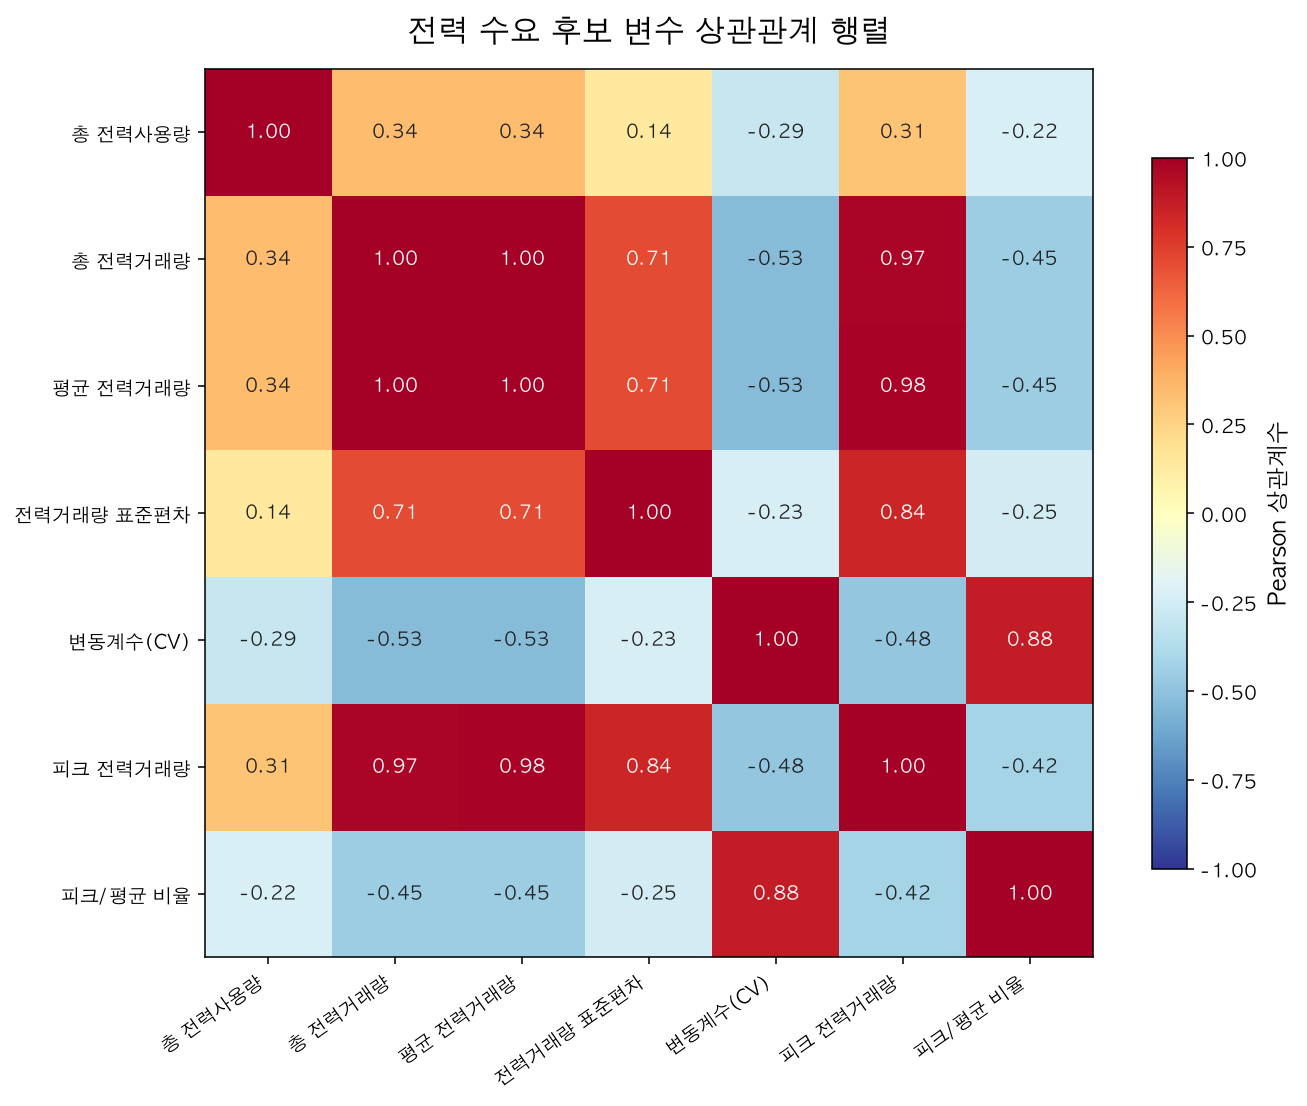

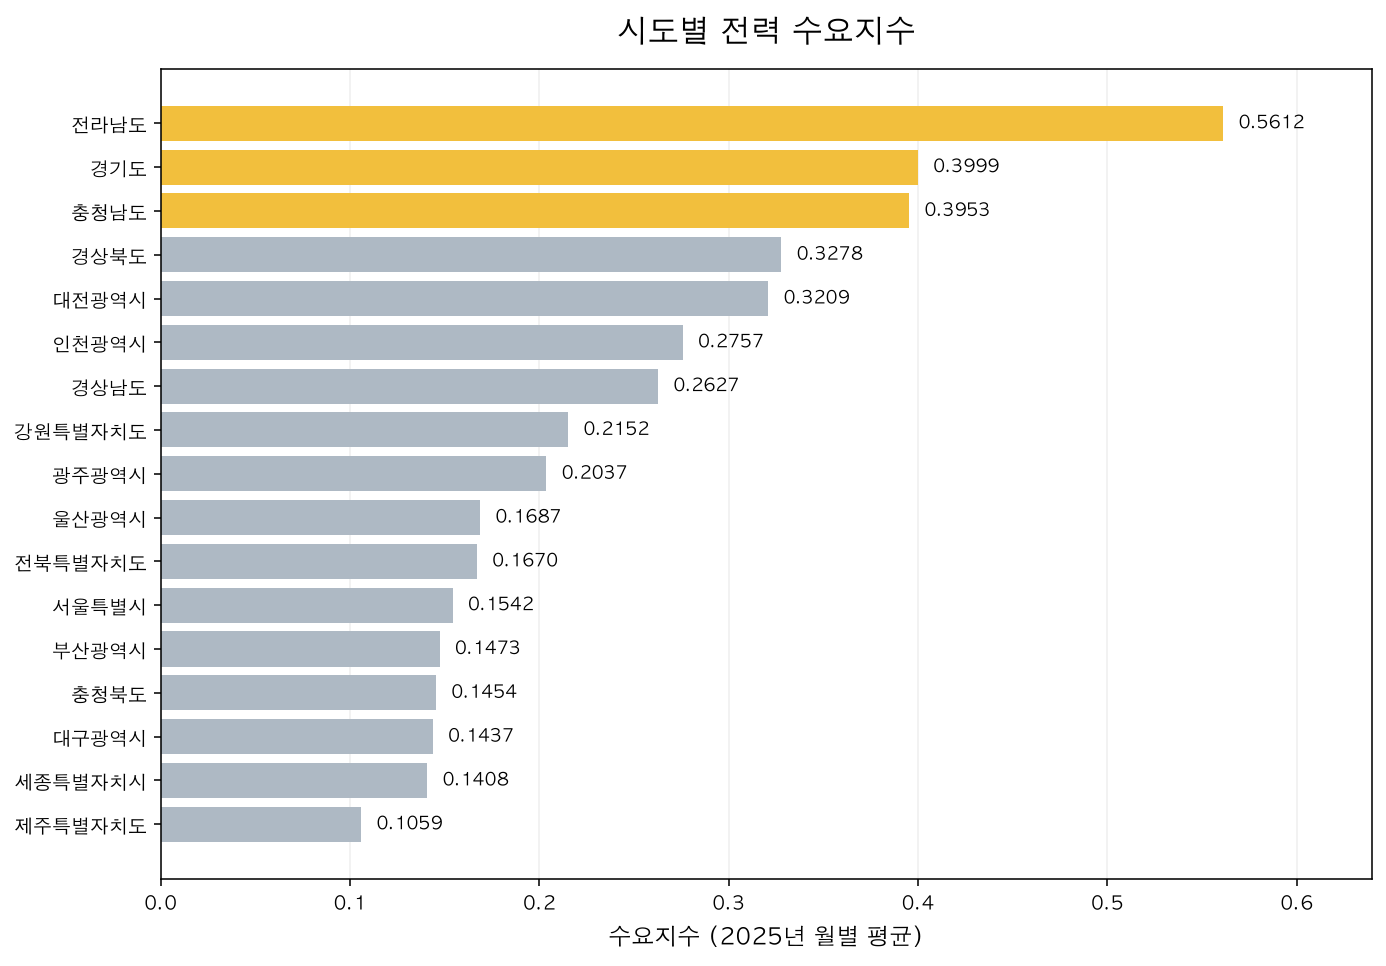

In [4]:
# 팀 전력수요 후보변수 분석 결과를 발표용으로 재현한다.
corr_labels = [
    "총 전력사용량", "총 전력거래량", "평균 전력거래량", "전력거래량 표준편차",
    "변동계수(CV)", "피크 전력거래량", "피크/평균 비율",
]
corr_values = np.array([
    [ 1.00,  0.34,  0.34,  0.14, -0.29,  0.31, -0.22],
    [ 0.34,  1.00,  1.00,  0.71, -0.53,  0.97, -0.45],
    [ 0.34,  1.00,  1.00,  0.71, -0.53,  0.98, -0.45],
    [ 0.14,  0.71,  0.71,  1.00, -0.23,  0.84, -0.25],
    [-0.29, -0.53, -0.53, -0.23,  1.00, -0.48,  0.88],
    [ 0.31,  0.97,  0.98,  0.84, -0.48,  1.00, -0.42],
    [-0.22, -0.45, -0.45, -0.25,  0.88, -0.42,  1.00],
])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_values, cmap="RdYlBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_labels)), corr_labels, rotation=35, ha="right")
ax.set_yticks(range(len(corr_labels)), corr_labels)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        color = "white" if abs(corr_values[i, j]) >= 0.65 else "#222222"
        ax.text(j, i, f"{corr_values[i, j]:.2f}", ha="center", va="center", color=color, fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson 상관계수")
ax.set_title("전력 수요 후보 변수 상관관계 행렬", pad=14)
plt.tight_layout()
plt.show()

demand_plot = area.sort_values("DEMAND_INDEX", ascending=True)
demand_colors = ["#d9d9d9"] * len(demand_plot)
top3_idx = demand_plot.nlargest(3, "DEMAND_INDEX").index
demand_colors = ["#f2bf3d" if idx in top3_idx else "#aeb9c4" for idx in demand_plot.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(demand_plot["REGION"], demand_plot["DEMAND_INDEX"], color=demand_colors)
for bar, value in zip(bars, demand_plot["DEMAND_INDEX"]):
    ax.text(value + 0.008, bar.get_y() + bar.get_height()/2, f"{value:.4f}", va="center", fontsize=9)
ax.set_title("시도별 전력 수요지수", pad=14)
ax.set_xlabel("수요지수 (2025년 월별 평균)")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
ax.margins(x=0.14)
plt.tight_layout()
plt.show()

## 3. 지역사회 건강부담 보조 분석

암 발생률·흡연율·고령화율·산업구조를 결합했지만, 송전시설 부담과의 관계는 통계적으로 유의하지 않았다. 따라서 건강 결과는 인과관계가 아닌 지역 단위 탐색 결과로 제시한다.

In [5]:
health_cols = ["REGION", "CANCER_ASR_PER_100K", "SMOKING_ASR_AVG_PCT", "AGING_RATE_AVG_PCT", "HEALTH_BURDEN_SCORE_0_100"]
display(integrated[health_cols].sort_values("HEALTH_BURDEN_SCORE_0_100", ascending=False).head(10))


,REGION,CANCER_ASR_PER_100K,SMOKING_ASR_AVG_PCT,AGING_RATE_AVG_PCT,HEALTH_BURDEN_SCORE_0_100
16,부산광역시,525.9,21.92,14.985538,100.000000
2,충청남도,508.2,23.28,16.547362,98.270383
1,경상북도,501.1,23.40,18.109532,97.211289
0,전라남도,502.5,21.68,20.785490,91.950010
9,충청북도,503.4,23.22,15.080338,82.186311
7,전북특별자치도,503.8,21.38,18.062212,75.500728
5,강원특별자치도,481.5,24.08,17.169848,70.451059
6,경상남도,508.9,21.90,14.095296,68.646378
11,대구광역시,513.9,21.60,13.021291,66.798068
4,인천광역시,499.7,23.98,10.908708,63.657088


## 4. 제조공정 AI 예측 및 생산시간 분산

공개 제조공정 데이터의 생산량·시간·기상·작업인원으로 평균 전력사용량을 예측했다. 아래 점 분포는 동일 데이터와 모델 흐름의 재현 결과이며, 표기한 **R²=0.8995는 팀 최종 실행에서 확정한 성능값**이다.

이후 생산량을 줄이지 않고 고부하 시간대 생산 일부를 저부하 시간대로 이동하는 시나리오를 적용했다.

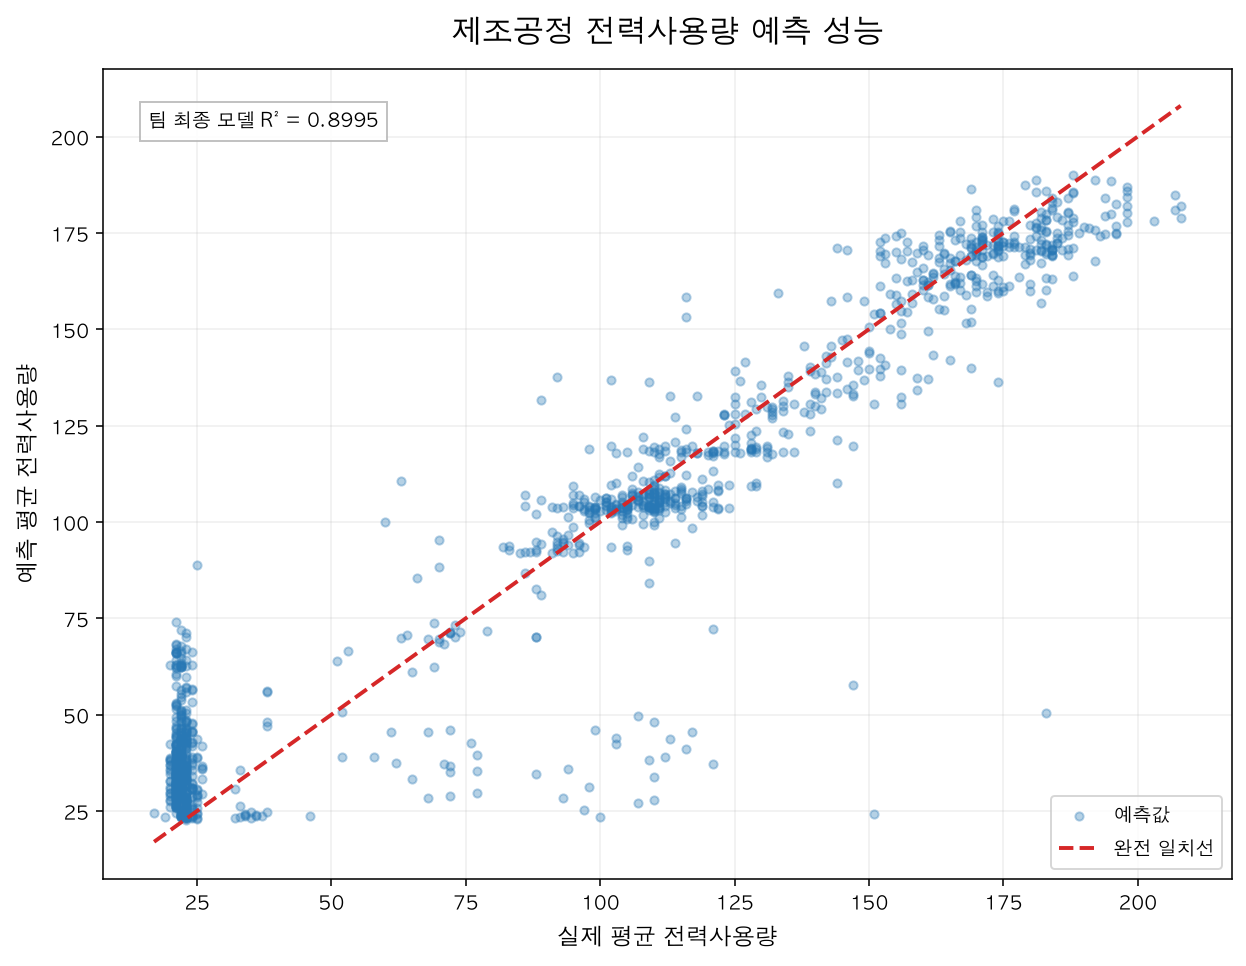

동일 데이터·모델 흐름 로컬 재현 R²: 0.9094


In [6]:
features = ["HOUR", "PRODUCTION_QTY", "TEMPERATURE", "WIND_SPEED", "HUMIDITY", "PRECIPITATION", "FACTORY_WORKERS"]
target = "AVG_POWER"
model_df = manufacturing.dropna(subset=features + [target]).sort_values(["DATE_ID", "HOUR"]).reset_index(drop=True)
split = int(len(model_df) * 0.8)
X_train, X_test = model_df.loc[:split-1, features], model_df.loc[split:, features]
y_train, y_test = model_df.loc[:split-1, target], model_df.loc[split:, target]

model = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=3,
    random_state=42, n_jobs=-1,
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
reproduced_r2 = r2_score(y_test, pred)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, pred, s=18, alpha=0.34, color="#2878b5", label="예측값")
lo, hi = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
ax.plot([lo, hi], [lo, hi], "--", color="#d62728", linewidth=2, label="완전 일치선")
ax.text(0.04, 0.95, "팀 최종 모델 R² = 0.8995", transform=ax.transAxes, va="top",
        bbox=dict(facecolor="white", alpha=0.92, edgecolor="#bbbbbb"))
ax.set_title("제조공정 전력사용량 예측 성능", pad=14)
ax.set_xlabel("실제 평균 전력사용량")
ax.set_ylabel("예측 평균 전력사용량")
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"동일 데이터·모델 흐름 로컬 재현 R²: {reproduced_r2:.4f}")

,TRAIN_ROWS,TEST_ROWS,MAE,RMSE,R2
0,4896,1224,12.463097,18.299558,0.911204


,SHIFT_RATE,AVG_BEFORE_PEAK,AVG_AFTER_PEAK,AVG_REDUCTION_RATE_PCT,REDUCED_DAYS,UNCHANGED_DAYS,INCREASED_DAYS
0,10.0,137.408139,136.886663,0.301925,192,104,29
1,20.0,137.408139,136.362541,0.589422,190,101,38
2,30.0,137.408139,135.996575,0.710615,185,98,34
3,40.0,137.408139,135.334992,1.061594,188,98,40


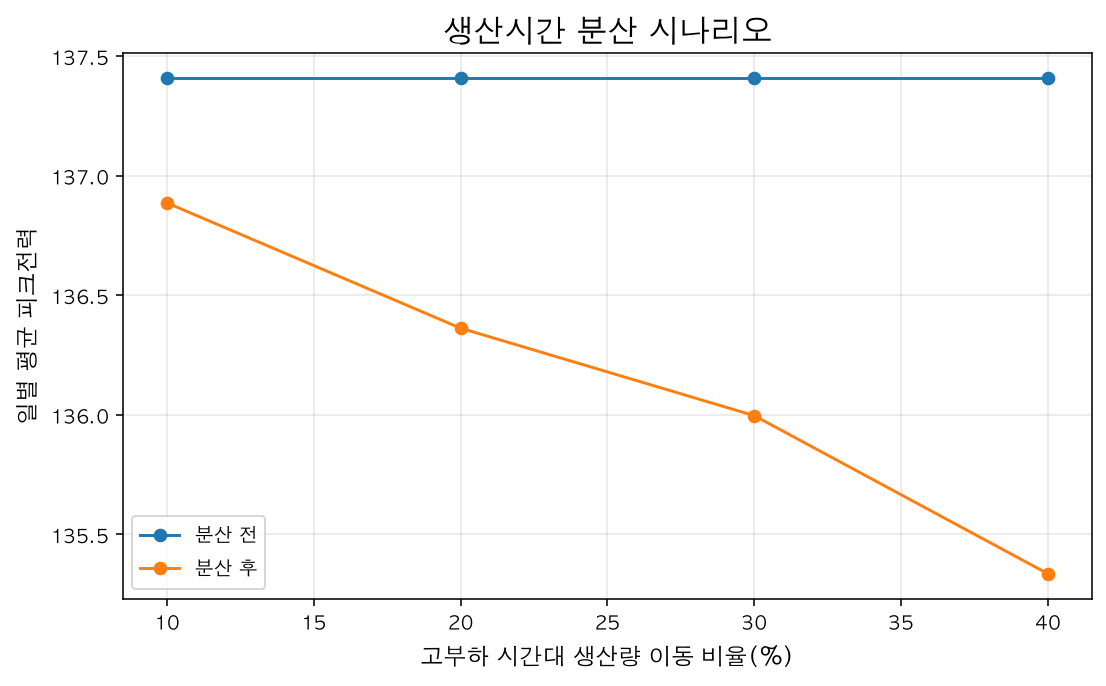

In [7]:
display(metrics)
display(scenario[["SHIFT_RATE", "AVG_BEFORE_PEAK", "AVG_AFTER_PEAK", "AVG_REDUCTION_RATE_PCT", "REDUCED_DAYS", "UNCHANGED_DAYS", "INCREASED_DAYS"]])

plt.figure(figsize=(8, 5))
plt.plot(scenario["SHIFT_RATE"], scenario["AVG_BEFORE_PEAK"], marker="o", label="분산 전")
plt.plot(scenario["SHIFT_RATE"], scenario["AVG_AFTER_PEAK"], marker="o", label="분산 후")
plt.xlabel("고부하 시간대 생산량 이동 비율(%)")
plt.ylabel("일별 평균 피크전력")
plt.title("생산시간 분산 시나리오")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,REGION,REGION_TOP5_HOURS,OVERLAP_HOURS,OVERLAP_RATE_PCT
0,전라남도,"17,18,15,16,14","14,15,16,18",80.0
1,경상북도,"20,21,19,22,23",NaN,0.0
2,충청남도,"20,19,21,18,22",18,20.0


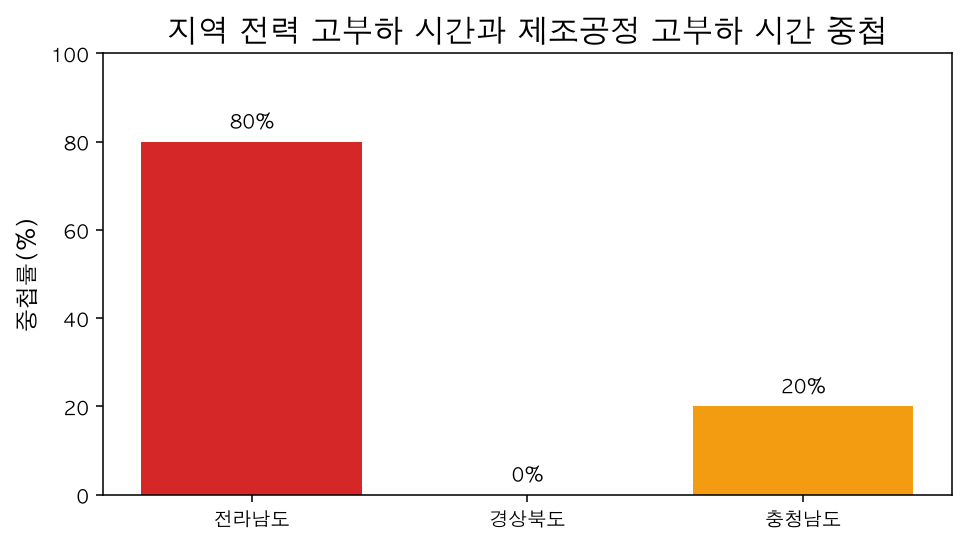

In [8]:
display(overlap[["REGION", "REGION_TOP5_HOURS", "OVERLAP_HOURS", "OVERLAP_RATE_PCT"]])
plt.figure(figsize=(7, 4))
plt.bar(overlap["REGION"], overlap["OVERLAP_RATE_PCT"], color=["#d62728", "#7f8c8d", "#f39c12"])
plt.ylabel("중첩률(%)")
plt.title("지역 전력 고부하 시간과 제조공정 고부하 시간 중첩")
plt.ylim(0, 100)
for i, value in enumerate(overlap["OVERLAP_RATE_PCT"]):
    plt.text(i, value + 3, f"{value:.0f}%", ha="center")
plt.tight_layout()
plt.show()

## 발표용 결론

- 면적보정 수요·인프라 비교에서 전남·경북·충남이 상대적 부담 가능성 상위 지역으로 나타났다.
- 건강부담 분석에서는 통계적으로 유의한 관계가 확인되지 않아 보조 결과로 해석한다.
- 대표 제조공정 데이터에서 40% 생산시간 분산 시 평균 피크가 약 1.06% 감소했고 총생산량은 유지됐다.
- 전남은 지역 전력 고부하 시간과 제조공정 고부하 시간의 중첩률이 80%로 나타나 수요관리 우선 적용 사례로 제안한다.

이 결과는 설비용량·선로부하율·실제 전남 개별업체의 감축량을 직접 측정한 것이 아니다. 따라서 “송전망 부족”이나 인과관계가 아니라 “상대적 부담 가능성”과 “적용 가능성”으로 표현한다.